# CDL Data Analysis

## Goal

The goal of this notebook is to answer interesting questions about
Call of Duty League teams, players, maps, and tournaments using data
collected from the CITO API.

Each section below contains a question, followed by the analysis used
to answer it.

In [24]:
import os
import requests
import pandas as pd
pd.set_option("display.max_columns", None)

from dotenv import load_dotenv

load_dotenv()

CITO_API_KEY = os.getenv("CITO_API_KEY")

if os.getenv("CITO_API_KEY"):
    print("API key loaded successfully")
else:
    print("API key not found or is empty")

API key loaded successfully


# Team Analysis

## Which team has the highest overall win rate based on tournaments and maps/modes?

In [3]:
# Get all organizations and saved them in a list
import json

teams_url = "https://api.citoapi.com/api/v1/cod/orgs?franchiseOnly=true&limit=12"

headers = {
    "x-api-key" : CITO_API_KEY
}

teams_response = requests.get(teams_url, headers=headers)
teams_response_json = teams_response.json()
teams_list = teams_response_json["data"]

slugs_list = []

for team in teams_list:
    slug_name = team["slug"]
    slugs_list.append(slug_name)

slugs_list

['boston-breach',
 'carolina-royal-ravens',
 'cloud9-new-york',
 'faze-vegas',
 'g2-minnesota',
 'los-angeles-thieves',
 'miami-heretics',
 'optic-texas',
 'paris-gentle-mates',
 'riyadh-falcons',
 'toronto-koi',
 'vancouver-surge']

In [10]:
# Now get results for all teams

# all_results = {}

# for slug_name in slugs_list:
#     team_results_url = f"https://api.citoapi.com/api/v1/cod/teams/{slug_name}/results"

#     team_results_response = requests.get(team_results_url, headers=headers)
#     team_results_json = team_results_response.json()

#     all_results[f"{slug_name}"] = team_results_json

# print(json.dumps(all_results, indent=4))

cdl_post_season_url = "https://api.citoapi.com/api/v1/cod/tournaments/codwiki-call-of-duty-league-championship-2026/matches"

post_season_matches_response = requests.get(cdl_post_season_url, headers=headers)
matches_json = post_season_matches_response.json()

# Convert response json to df

matches_df = pd.json_normalize(matches_json["data"])

# print raw data for all matches
matches_df



,id,matchId,bpMatchId,round,status,startsAt,matchDate,scheduledTime,bestOf,winnerSlug,tournament.tournamentId,tournament.name,tournament.game,tournament.tier,teams.team1.name,teams.team1.shortName,teams.team1.logoUrl,teams.team1.score,teams.team2.name,teams.team2.shortName,teams.team2.logoUrl,teams.team2.score,team1.name,team1.shortName,team1.logoUrl,team1.score,team2.name,team2.shortName,team2.logoUrl,team2.score,score.team1,score.team2,score.formatted,media.officialChannelFallbacks,tournament.season,tournament.bpEventId
0,679d7247-8d10-4623-a45d-a7c9f87748da,12911,215033.0,Grand Finals,completed,2026-07-19T22:00:00.000Z,2026-07-19T22:00:00.000Z,2026-07-19T22:00:00.000Z,9,faze-vegas,cdl-2026-championship,CDL 2026 Championship,bo6,S,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,5,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,5,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,5,2,5-2,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
1,4d772fec-623a-46ee-93bd-236d45e2597b,bp-match-215033,NaN,Grand Finals,stale,2026-07-19T19:00:00.000Z,2026-07-19T19:00:00.000Z,NaN,9,NaN,bp-110,CDL League Championship,bo6,Tournament,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,0,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,0,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,0,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,0,0,0,0-0,"[{'platform': 'youtube', 'url': 'https://www.y...",2025,110.0
2,bc14d8dd-70f5-474e-9a53-85dbc013acc5,bp-match-215032,NaN,Elimination Finals,stale,2026-07-19T01:40:00.000Z,2026-07-19T01:40:00.000Z,NaN,5,NaN,bp-110,CDL League Championship,bo6,Tournament,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,0,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,0,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,0,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,0,0,0,0-0,"[{'platform': 'youtube', 'url': 'https://www.y...",2025,110.0
3,88fa646a-3098-4835-bb70-4336d8c873f0,12918,215032.0,Elimination Finals,completed,2026-07-19T01:00:00.000Z,2026-07-19T01:00:00.000Z,2026-07-19T01:00:00.000Z,5,optic-texas,cdl-2026-championship,CDL 2026 Championship,bo6,S,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,1,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,1,3,1,3-1,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
4,eb4abde1-eb0b-4d18-9330-c3017c67ca9a,bp-match-215031,NaN,Elimination Round 3,stale_live,2026-07-18T23:53:09.420Z,2026-07-18T23:53:09.420Z,NaN,5,NaN,bp-110,CDL League Championship,bo6,Tournament,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,0,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,0,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,0,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,0,0,0,0-0,"[{'platform': 'youtube', 'url': 'https://www.y...",2025,110.0
5,a69f4116-9f10-4854-b7bd-f85c3f3ecdcf,12917,215031.0,Elimination Round 3,completed,2026-07-18T23:30:00.000Z,2026-07-18T23:30:00.000Z,2026-07-18T23:30:00.000Z,5,riyadh-falcons,cdl-2026-championship,CDL 2026 Championship,bo6,S,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,2,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,2,3,2,3-2,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
6,d9f8723f-b5ce-4ff9-902d-d98402bcbf36,12910,215030.0,Winners Finals,completed,2026-07-18T22:00:00.000Z,2026-07-18T22:00:00.000Z,2026-07-18T22:00:00.000Z,5,fa

In [15]:
# Now clean the data

# 1st: Remove any 'Status' columns that have 'Stale'

matches_df = matches_df[(matches_df["tournament.tournamentId"] == "cdl-2026-championship") & (matches_df["status"] == "completed")] .copy()
matches_df["matchDate"] = pd.to_datetime(matches_df["matchDate"])

matches_df = matches_df.sort_values("matchDate", ascending=False)
matches_df

,id,matchId,bpMatchId,round,status,startsAt,matchDate,scheduledTime,bestOf,winnerSlug,tournament.tournamentId,tournament.name,tournament.game,tournament.tier,teams.team1.name,teams.team1.shortName,teams.team1.logoUrl,teams.team1.score,teams.team2.name,teams.team2.shortName,teams.team2.logoUrl,teams.team2.score,team1.name,team1.shortName,team1.logoUrl,team1.score,team2.name,team2.shortName,team2.logoUrl,team2.score,score.team1,score.team2,score.formatted,media.officialChannelFallbacks,tournament.season,tournament.bpEventId
0,679d7247-8d10-4623-a45d-a7c9f87748da,12911,215033.0,Grand Finals,completed,2026-07-19T22:00:00.000Z,2026-07-19 22:00:00+00:00,2026-07-19T22:00:00.000Z,9,faze-vegas,cdl-2026-championship,CDL 2026 Championship,bo6,S,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,5,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,5,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,5,2,5-2,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
3,88fa646a-3098-4835-bb70-4336d8c873f0,12918,215032.0,Elimination Finals,completed,2026-07-19T01:00:00.000Z,2026-07-19 01:00:00+00:00,2026-07-19T01:00:00.000Z,5,optic-texas,cdl-2026-championship,CDL 2026 Championship,bo6,S,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,1,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,1,3,1,3-1,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
5,a69f4116-9f10-4854-b7bd-f85c3f3ecdcf,12917,215031.0,Elimination Round 3,completed,2026-07-18T23:30:00.000Z,2026-07-18 23:30:00+00:00,2026-07-18T23:30:00.000Z,5,riyadh-falcons,cdl-2026-championship,CDL 2026 Championship,bo6,S,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,2,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,2,3,2,3-2,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
6,d9f8723f-b5ce-4ff9-902d-d98402bcbf36,12910,215030.0,Winners Finals,completed,2026-07-18T22:00:00.000Z,2026-07-18 22:00:00+00:00,2026-07-18T22:00:00.000Z,5,faze-vegas,cdl-2026-championship,CDL 2026 Championship,bo6,S,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,3,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,3,2,3,2-3,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
7,07bc2269-496e-42b8-b248-bbb170782e28,12915,215029.0,Elimination Round 2,completed,2026-07-18T20:30:00.000Z,2026-07-18 20:30:00+00:00,2026-07-18T20:30:00.000Z,5,riyadh-falcons,cdl-2026-championship,CDL 2026 Championship,bo6,S,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,3,Miami Heretics,MIA,https://api.citoapi.com/api/v1/public/images/c...,0,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,3,Miami Heretics,MIA,https://api.citoapi.com/api/v1/public/images/c...,0,3,0,3-0,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
8,d2e0ab6c-8d55-419b-a6ed-21a2b1d574a6,12916,215028.0,Elimination Round 2,completed,2026-07-18T19:00:00.000Z,2026-07-18 19:00:00+00:00,2026-07-18T19:00:00.000Z,5,paris-gentle-mates,cdl-2026-championship,CDL 2026 Championship,bo6,S,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,G2 Minnesota,MIN,https://api.citoapi.com/api/v1/public/images/c...,0,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,G2 Minnesota,MIN,https://api.citoapi.com/api/v1/public/images/c...,0,3,0,3-0,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN
9,8c737083-ce12-4a38-8952-0e3a6dfd3fec,12908,215026.0,

In [20]:
matches_df["matchDateEastern"] = (matches_df["matchDate"].dt.tz_convert("America/New_York"))
matches_df["bpMatchId"] = matches_df["bpMatchId"].astype(int)
matches_df

,id,matchId,bpMatchId,round,status,startsAt,matchDate,scheduledTime,bestOf,winnerSlug,tournament.tournamentId,tournament.name,tournament.game,tournament.tier,teams.team1.name,teams.team1.shortName,teams.team1.logoUrl,teams.team1.score,teams.team2.name,teams.team2.shortName,teams.team2.logoUrl,teams.team2.score,team1.name,team1.shortName,team1.logoUrl,team1.score,team2.name,team2.shortName,team2.logoUrl,team2.score,score.team1,score.team2,score.formatted,media.officialChannelFallbacks,tournament.season,tournament.bpEventId,matchDateEastern
0,679d7247-8d10-4623-a45d-a7c9f87748da,12911,215033,Grand Finals,completed,2026-07-19T22:00:00.000Z,2026-07-19 22:00:00+00:00,2026-07-19T22:00:00.000Z,9,faze-vegas,cdl-2026-championship,CDL 2026 Championship,bo6,S,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,5,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,5,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,5,2,5-2,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN,2026-07-19 18:00:00-04:00
3,88fa646a-3098-4835-bb70-4336d8c873f0,12918,215032,Elimination Finals,completed,2026-07-19T01:00:00.000Z,2026-07-19 01:00:00+00:00,2026-07-19T01:00:00.000Z,5,optic-texas,cdl-2026-championship,CDL 2026 Championship,bo6,S,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,1,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,1,3,1,3-1,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN,2026-07-18 21:00:00-04:00
5,a69f4116-9f10-4854-b7bd-f85c3f3ecdcf,12917,215031,Elimination Round 3,completed,2026-07-18T23:30:00.000Z,2026-07-18 23:30:00+00:00,2026-07-18T23:30:00.000Z,5,riyadh-falcons,cdl-2026-championship,CDL 2026 Championship,bo6,S,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,2,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,2,3,2,3-2,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN,2026-07-18 19:30:00-04:00
6,d9f8723f-b5ce-4ff9-902d-d98402bcbf36,12910,215030,Winners Finals,completed,2026-07-18T22:00:00.000Z,2026-07-18 22:00:00+00:00,2026-07-18T22:00:00.000Z,5,faze-vegas,cdl-2026-championship,CDL 2026 Championship,bo6,S,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,3,OpTic Texas,TX,https://api.citoapi.com/api/v1/public/images/c...,2,FaZe Vegas,FV,https://api.citoapi.com/api/v1/public/images/c...,3,2,3,2-3,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN,2026-07-18 18:00:00-04:00
7,07bc2269-496e-42b8-b248-bbb170782e28,12915,215029,Elimination Round 2,completed,2026-07-18T20:30:00.000Z,2026-07-18 20:30:00+00:00,2026-07-18T20:30:00.000Z,5,riyadh-falcons,cdl-2026-championship,CDL 2026 Championship,bo6,S,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,3,Miami Heretics,MIA,https://api.citoapi.com/api/v1/public/images/c...,0,Riyadh Falcons,RYD,https://api.citoapi.com/api/v1/public/images/c...,3,Miami Heretics,MIA,https://api.citoapi.com/api/v1/public/images/c...,0,3,0,3-0,"[{'platform': 'youtube', 'url': 'https://www.y...",NaN,NaN,2026-07-18 16:30:00-04:00
8,d2e0ab6c-8d55-419b-a6ed-21a2b1d574a6,12916,215028,Elimination Round 2,completed,2026-07-18T19:00:00.000Z,2026-07-18 19:00:00+00:00,2026-07-18T19:00:00.000Z,5,paris-gentle-mates,cdl-2026-championship,CDL 2026 Championship,bo6,S,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,G2 Minnesota,MIN,https://api.citoapi.com/api/v1/public/images/c...,0,Paris Gentle Mates,M8,https://api.citoapi.com/api/v1/public/images/c...,3,G2 Minnesota,MIN,https://api.citoapi.com/api/v1/public/i

In [27]:
print(json.dumps(matches_df.to_dict("records"), indent=4, default=str))

[
    {
        "id": "679d7247-8d10-4623-a45d-a7c9f87748da",
        "matchId": "12911",
        "bpMatchId": 215033,
        "round": "Grand Finals",
        "status": "completed",
        "startsAt": "2026-07-19T22:00:00.000Z",
        "matchDate": "2026-07-19 22:00:00+00:00",
        "scheduledTime": "2026-07-19T22:00:00.000Z",
        "bestOf": 9,
        "winnerSlug": "faze-vegas",
        "tournament.tournamentId": "cdl-2026-championship",
        "tournament.name": "CDL 2026 Championship",
        "tournament.game": "bo6",
        "tournament.tier": "S",
        "teams.team1.name": "FaZe Vegas",
        "teams.team1.shortName": "FV",
        "teams.team1.logoUrl": "https://api.citoapi.com/api/v1/public/images/cod/aHR0cHM6Ly9kZnBpaXVmeGNjaXVqdWd6anZneC5zdXBhYmFzZS5jby9zdG9yYWdlL3YxL29iamVjdC9wdWJsaWMvdGVhbXMvVGVhbSUyMExvZ29zL0ZhWmVfVmVnYXNsb2dvX3NxdWFyZS53ZWJw",
        "teams.team1.score": 5,
        "teams.team2.name": "OpTic Texas",
        "teams.team2.shortName": "TX",
    

In [36]:
# Each row has only one winner. So for each row create a list of dicts where it saves the winner and loser
all_games = {}
win_lose_list = []
num_games = 0
for match in matches_df.to_dict("records"):

    round = match["round"]
    team1 = match["team1.name"]
    team2 = match["team2.name"]
    team1_score = int(match["score.team1"])
    team2_score = int(match["score.team2"])

    win_lose = {
        "Round" : round
    }

    # If team1 wins then add team 1 name as winner and team 2 as loser in dict
    if team1_score > team2_score:
        win_lose["Winner"] = team1
        win_lose["Loser"] = team2
    else:
        win_lose["Winner"] = team2
        win_lose["Loser"] = team1

    win_lose_list.append(win_lose)

    num_games += 1

all_games["Games List"] = win_lose_list
all_games["count"] = num_games
print(json.dumps(all_games, indent=4))



{
    "Games List": [
        {
            "Round": "Grand Finals",
            "Winner": "FaZe Vegas",
            "Loser": "OpTic Texas"
        },
        {
            "Round": "Elimination Finals",
            "Winner": "OpTic Texas",
            "Loser": "Riyadh Falcons"
        },
        {
            "Round": "Elimination Round 3",
            "Winner": "Paris Gentle Mates",
            "Loser": "Riyadh Falcons"
        },
        {
            "Round": "Winners Finals",
            "Winner": "FaZe Vegas",
            "Loser": "OpTic Texas"
        },
        {
            "Round": "Elimination Round 2",
            "Winner": "Riyadh Falcons",
            "Loser": "Miami Heretics"
        },
        {
            "Round": "Elimination Round 2",
            "Winner": "Paris Gentle Mates",
            "Loser": "G2 Minnesota"
        },
        {
            "Round": "Winners Round 2",
            "Winner": "OpTic Texas",
            "Loser": "Paris Gentle Mates"
        },
    

In [53]:
# Now we have to calculate the number of wins, loses, and total matches played. 
# We can easily find the total matches by adding wins and loses.

# dict of what I need to collect 
# {
#   "Team Name" : {
#       "Wins" : #, 
#       "Loses": #, 
#       "Total Matches": #
#   },
#   "Team Name" : {
#       "Wins" : #, 
#       "Loses": #, 
#       "Total Matches": #
#   }
# }

teams_win_lose_dict = {}

for round in all_games["Games List"]:
    team1 = round["Winner"]
    team2 = round["Loser"]

    # If team1 exists in the dict then just add 1 to 'Wins' since team 1 is the winner.
    if team1 in teams_win_lose_dict:
        teams_win_lose_dict[team1]["Wins"] += 1
        teams_win_lose_dict[team1]["Total Matches"] += 1
    # If team1 does not exist then add its name to the dict and add the rest of the dictionary
    else:
        results = {
            "Wins" : 1,
            "Losses" : 0,
            "Total Matches" : 1 + 0
        }

        teams_win_lose_dict[team1] = results

    if team2 in teams_win_lose_dict:
        teams_win_lose_dict[team2]["Losses"] += 1
        teams_win_lose_dict[team2]["Total Matches"] += 1
    else:
        results = {
                    "Wins" : 0,
                    "Losses" : 1,
                    "Total Matches" : 1 + 0
        }
        teams_win_lose_dict[team2] = results

for team, stats in teams_win_lose_dict.items():
    tournament_win_rate = (stats["Wins"]/stats["Total Matches"]) * 100
    stats["Win Rate"] = tournament_win_rate

print(json.dumps(teams_win_lose_dict, indent=4))




{
    "FaZe Vegas": {
        "Wins": 4,
        "Losses": 0,
        "Total Matches": 4,
        "Win Rate": 100.0
    },
    "OpTic Texas": {
        "Wins": 3,
        "Losses": 2,
        "Total Matches": 5,
        "Win Rate": 60.0
    },
    "Riyadh Falcons": {
        "Wins": 2,
        "Losses": 3,
        "Total Matches": 5,
        "Win Rate": 40.0
    },
    "Paris Gentle Mates": {
        "Wins": 3,
        "Losses": 1,
        "Total Matches": 4,
        "Win Rate": 75.0
    },
    "Miami Heretics": {
        "Wins": 1,
        "Losses": 2,
        "Total Matches": 3,
        "Win Rate": 33.33333333333333
    },
    "G2 Minnesota": {
        "Wins": 1,
        "Losses": 2,
        "Total Matches": 3,
        "Win Rate": 33.33333333333333
    },
    "Los Angeles Thieves": {
        "Wins": 0,
        "Losses": 2,
        "Total Matches": 2,
        "Win Rate": 0.0
    },
    "Toronto KOI": {
        "Wins": 0,
        "Losses": 2,
        "Total Matches": 2,
        "Win Ra

## Match Win Rate by Team - 2026 CDL Championship

Matplotlib is building the font cache; this may take a moment.


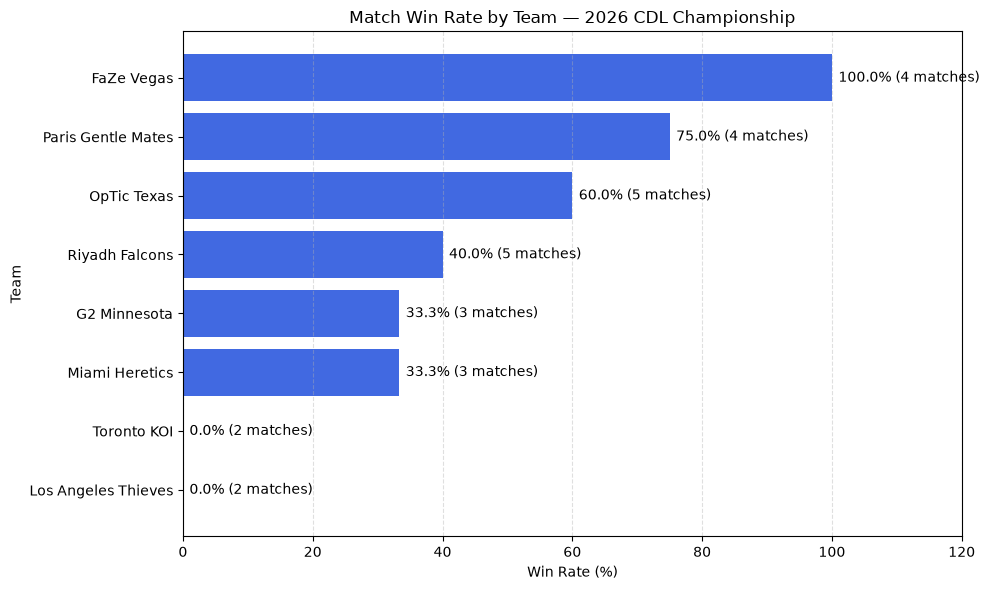

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the dictionary into a DataFrame
win_rate_df = (
    pd.DataFrame.from_dict(
        teams_win_lose_dict,
        orient="index"
    )
    .reset_index()
    .rename(columns={"index": "Team"})
)

# Sort from highest to lowest win rate
win_rate_df = win_rate_df.sort_values(
    "Win Rate",
    ascending=True
)

# Create the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    win_rate_df["Team"],
    win_rate_df["Win Rate"],
    color="royalblue"
)

# Add win rate and total-match labels
for bar, win_rate, total_matches in zip(
    bars,
    win_rate_df["Win Rate"],
    win_rate_df["Total Matches"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{win_rate:.1f}% ({total_matches} matches)",
        va="center"
    )

ax.set_title(
    "Match Win Rate by Team — 2026 CDL Championship"
)
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Team")
ax.set_xlim(0, 120)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

FaZe Vegas achieved the highest match win rate at the 2026 CDL Championship, winning all four matches it played. Teams played different numbers of matches because the double-elimination bracket allowed teams advancing through different paths to play more matches. Therefore, win rates should be considered alongside each team’s total matches played.

In [25]:
# 2. Now use matches_df to find each map for all individual matches.

# There are 14 matches in total. Make 14 different dataframes for all matches

match_dataframes = []

for bp_match_id in matches_df["bpMatchId"]:
    bp_match_id = int(bp_match_id)

    match_url = f"https://api.citoapi.com/api/v1/cod/matches/{bp_match_id}"

    response = requests.get(match_url, headers=headers)

    if response.ok:
        response_json = response.json()
        match_df = pd.json_normalize(response_json["data"])

        match_dataframes.append(match_df)
    else:
        print(
            f"Failed for {bp_match_id}: "
            f"{response.status_code}"
        )

if match_dataframes:
    all_match_details_df = pd.concat(match_dataframes, ignore_index=True)

    display(all_match_details_df)

,id,matchId,round,team1Score,team2Score,winnerSlug,mapScores,matchDate,status,vodUrl,playerStats,maps,team1.slug,team1.name,team1.logoUrl,team2.slug,team2.name,team2.logoUrl,media.liveStreamUrl,media.replayUrl,media.vodUrl,media.officialChannelFallbacks,tournament.tournamentId,tournament.name,tournament.game,tournament.startDate,tournament.streamUrl
0,679d7247-8d10-4623-a45d-a7c9f87748da,12911,Grand Finals,5,2,faze-vegas,None,2026-07-19T22:00:00.000Z,completed,None,"[{'playerName': 'Drazah', 'orgSlug': 'faze-veg...","[{'mapNumber': 1, 'mapName': 'Colossus', 'mapI...",faze-vegas,FaZe Vegas,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,optic-texas,OpTic Texas,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-2026-championship,CDL 2026 Championship,bo6,2026-01-01T00:00:00.000Z,None
1,88fa646a-3098-4835-bb70-4336d8c873f0,12918,Elimination Finals,3,1,optic-texas,None,2026-07-19T01:00:00.000Z,completed,None,"[{'playerName': 'Huke', 'orgSlug': 'optic-texa...","[{'mapNumber': 1, 'mapName': 'Hacienda', 'mapI...",optic-texas,OpTic Texas,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,riyadh-falcons,Riyadh Falcons,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-2026-championship,CDL 2026 Championship,bo6,2026-01-01T00:00:00.000Z,None
2,a69f4116-9f10-4854-b7bd-f85c3f3ecdcf,12917,Elimination Round 3,3,2,riyadh-falcons,None,2026-07-18T23:30:00.000Z,completed,None,"[{'playerName': 'JoeDeceives', 'orgSlug': 'par...","[{'mapNumber': 1, 'mapName': 'Den', 'mapImageU...",paris-gentle-mates,Paris Gentle Mates,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,riyadh-falcons,Riyadh Falcons,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-2026-championship,CDL 2026 Championship,bo6,2026-01-01T00:00:00.000Z,None
3,d9f8723f-b5ce-4ff9-902d-d98402bcbf36,12910,Winners Finals,2,3,faze-vegas,None,2026-07-18T22:00:00.000Z,completed,None,"[{'playerName': 'Simp', 'orgSlug': 'faze-vegas...","[{'mapNumber': 1, 'mapName': 'Scar', 'mapImage...",optic-texas,OpTic Texas,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,faze-vegas,FaZe Vegas,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-2026-championship,CDL 2026 Championship,bo6,2026-01-01T00:00:00.000Z,None
4,07bc2269-496e-42b8-b248-bbb170782e28,12915,Elimination Round 2,3,0,riyadh-falcons,None,2026-07-18T20:30:00.000Z,completed,None,"[{'playerName': 'ReeaL', 'orgSlug': 'miami-her...","[{'mapNumber': 1, 'mapName': 'Hacienda', 'mapI...",riyadh-falcons,Riyadh Falcons,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,miami-heretics,Miami Heretics,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-2026-championship,CDL 2026 Championship,bo6,2026-01-01T00:00:00.000Z,None
5,d2e0ab6c-8d55-419b-a6ed-21a2b1d574a6,12916,Elimination Round 2,3,0,paris-gentle-mates,None,2026-07-18T19:00:00.000Z,completed,None,"[{'playerName': 'Nastie', 'orgSlug': 'g2-minne...","[{'mapNumber': 1, 'mapName': 'Den', 'mapImageU...",paris-gentle-mates,Paris Gentle Mates,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,g2-minnesota,G2 Minnesota,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-2026-championship,CDL 2026 Championship,bo6,2026-01-01T00:00:00.000Z,None
6,8c737083-ce12-4a38-8952-0e3a6dfd3fec,12908,Winners Round 2,3,1,optic-texas,None,2026-07-17T23:30:00.000Z,completed,None,"[{'playerName': 'Huke', 'orgSlug': 'optic-texa...","[{'mapNumber': 1, 'mapName': 'Scar', 'mapImage...",optic-texas,OpTic Texas,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,paris-gentle-mates,Paris Gentle Mates,https://dfpiiufxcciujugzjvgx.supabase.co/stora...,None,None,None,"[{'platform': 'youtube', 'url': 'https://www.y...",cdl-202